<a href="https://colab.research.google.com/github/harryongit/Analysis-of-Zomato-Delivery-Operations-for-Delivery-Time-Prediction-and-Logistics-Optimization/blob/main/fooddeliveryanalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Zomato Dataset.csv")
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
df.info()

Shape: (45584, 20)

Columns:
 ['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)']

Missing values:
 ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_v

In [ ]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("-", "_")
print(df.columns.tolist())

['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken_(min)']


In [ ]:
if "Time_taken(min)" in df.columns:
    df.rename(columns={"Time_taken(min)": "Time_taken_min"}, inplace=True)
elif "Time_taken_(min)" in df.columns:
    df.rename(columns={"Time_taken_(min)": "Time_taken_min"}, inplace=True)
elif "Time_taken_(min)" not in df.columns and "Time_taken_min" not in df.columns:
    for col in df.columns:
        if "Time_taken" in col:
            df.rename(columns={col: "Time_taken_min"}, inplace=True)

print(df.columns.tolist())

['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken_min']


In [ ]:
numeric_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Vehicle_condition",
    "multiple_deliveries",
    "Time_taken_min"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[numeric_cols].head())

   Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  \
0                 36.0                      4.2            30.327968   
1                 21.0                      4.7            10.003064   
2                 23.0                      4.7            18.562450   
3                 34.0                      4.3            30.899584   
4                 24.0                      4.7            26.463504   

   Restaurant_longitude  Delivery_location_latitude  \
0             78.046106                   30.397968   
1             76.307589                   10.043064   
2             73.916619                   18.652450   
3             75.809346                   30.919584   
4             80.372929                   26.593504   

   Delivery_location_longitude  Vehicle_condition  multiple_deliveries  \
0                    78.116106                  2                  3.0   
1                    76.347589                  1                  1.0   
2             

In [ ]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y", errors="coerce")

df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M", errors="coerce")
df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], format="%H:%M", errors="coerce")

In [ ]:
def time_diff_minutes(start, end):
    if pd.isnull(start) or pd.isnull(end):
        return np.nan
    diff = (end - start).total_seconds() / 60
    if diff < 0:
        diff += 24 * 60
    return diff

df["prep_time_min"] = df.apply(
    lambda row: time_diff_minutes(row["Time_Orderd"], row["Time_Order_picked"]), axis=1
)

df[["Time_Orderd", "Time_Order_picked", "prep_time_min"]].head()

,Time_Orderd,Time_Order_picked,prep_time_min
0,1900-01-01 21:55:00,1900-01-01 22:10:00,15.0
1,1900-01-01 14:55:00,1900-01-01 15:05:00,10.0
2,1900-01-01 17:30:00,1900-01-01 17:40:00,10.0
3,1900-01-01 09:20:00,1900-01-01 09:30:00,10.0
4,1900-01-01 19:50:00,1900-01-01 20:05:00,15.0


In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df["distance_km"] = haversine(
    df["Restaurant_latitude"],
    df["Restaurant_longitude"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"]
)

df[["Restaurant_latitude", "Restaurant_longitude",
    "Delivery_location_latitude", "Delivery_location_longitude",
    "distance_km"]].head()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,distance_km
0,30.327968,78.046106,30.397968,78.116106,10.280582
1,10.003064,76.307589,10.043064,76.347589,6.242319
2,18.562450,73.916619,18.652450,74.006619,13.787860
3,30.899584,75.809346,30.919584,75.829346,2.930258
4,26.463504,80.372929,26.593504,80.502929,19.396618


In [ ]:
df = df[
    (df["Time_taken_min"].notnull()) &
    (df["distance_km"].notnull()) &
    (df["distance_km"] > 0)
]

df = df[df["Time_taken_min"] > 0]

print("Cleaned shape:", df.shape)

Cleaned shape: (45584, 22)


In [ ]:
num_fill_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "multiple_deliveries", "prep_time_min"]
cat_fill_cols = ["Weather_conditions", "Road_traffic_density", "Type_of_order",
                 "Type_of_vehicle", "Festival", "City"]

for col in num_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

for col in cat_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    5799
Time_Order_picked              5007
Weather_conditions                0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken_min                    0
prep_time_min                     0
distance_km                       0
dtype: int64


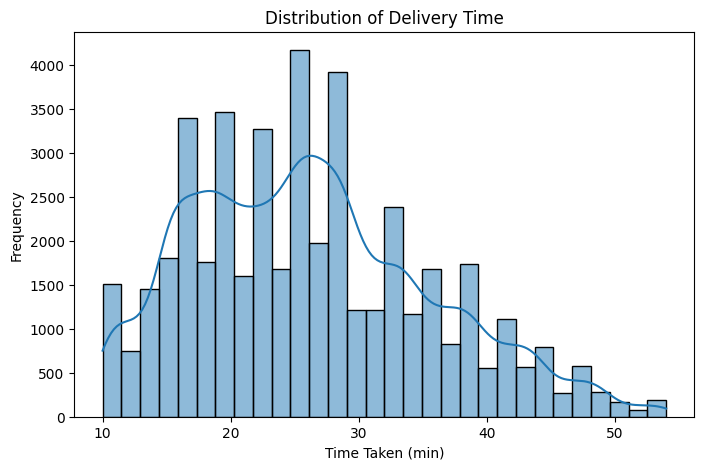

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Time_taken_min"], bins=30, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Time Taken (min)")
plt.ylabel("Frequency")
plt.show()

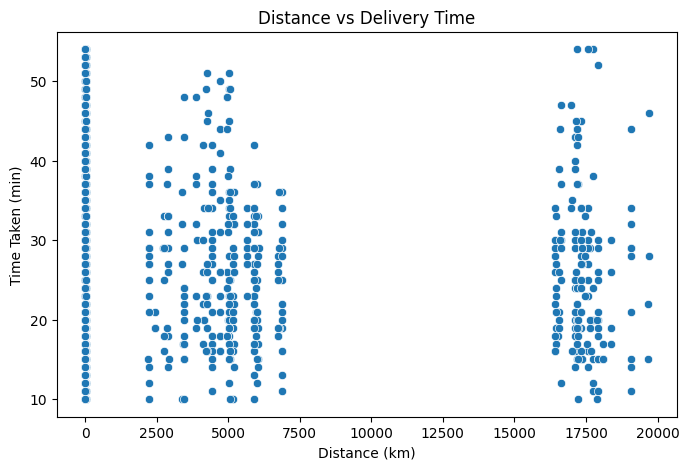

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["distance_km"], y=df["Time_taken_min"])
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Time Taken (min)")
plt.show()

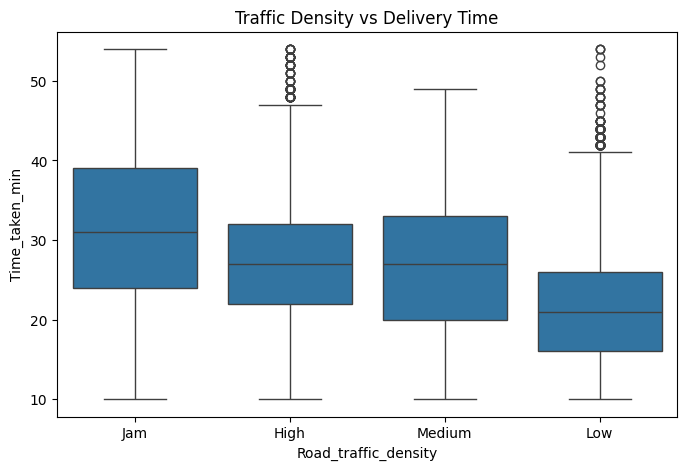

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Road_traffic_density", y="Time_taken_min", data=df)
plt.title("Traffic Density vs Delivery Time")
plt.show()

In [ ]:
corr_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "Vehicle_condition",
             "multiple_deliveries", "prep_time_min", "distance_km", "Time_taken_min"]

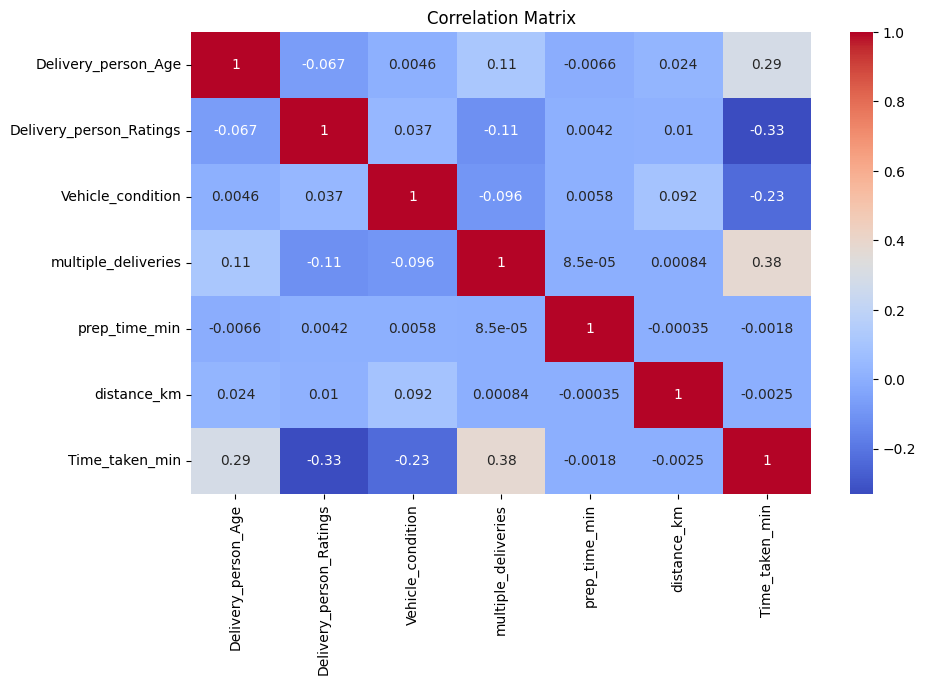

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "prep_time_min",
    "distance_km",
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

target = "Time_taken_min"

X = df[features]
y = df[target]

numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "prep_time_min",
    "distance_km"
]

categorical_features = [
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 3.2123494570582425
RMSE: 4.081153981883747
R2 Score: 0.8111812247911403


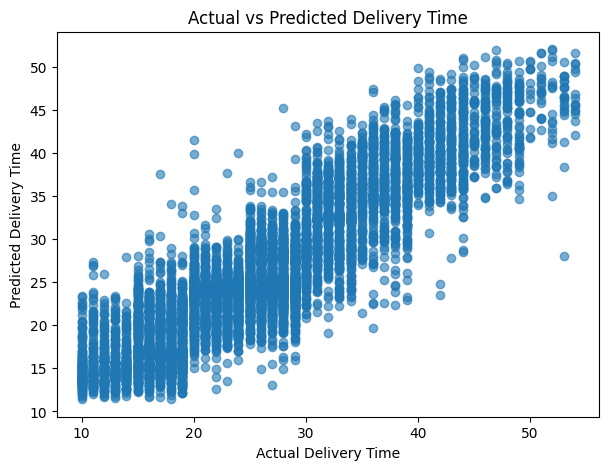

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

In [ ]:
df.to_csv("cleaned_zomato_dataset.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
